# GeoDiff 3x: residual base and routed diffusion on your Landsat/Sentinel tiles

**This notebook does not use OLI2MSI or RDN.** Attach your Landsat 8/9 Collection 2
Level-2 products and Sentinel-2 L2A SAFE products, as in the existing real-pair notebook.
It calls the same `prepare_landsat_sentinel` pipeline: metadata scaling, QA masks,
date/footprint matching, aligned 30 m LR and 10 m HR, and per-tile spatial splits.

Main controlled runs, in separate cells:
1. Updated residual-group Swin-style base only.
2. That base + one velocity expert.
3. That base + generic routed velocity experts.
4. That base + base-relative reliability-supervised experts.

The five earlier loss/input profiles are also available as **optional new controlled
re-runs**. Their old notebooks, checkpoints and output folders are not edited. These
re-runs disable perceptual/GAN losses, shrink the shared diffusion trunk, and remove
PixelShuffle everywhere, so they are **not exact reproductions of historical numbers**.

Start with the smoke profile. After checking pairing and runtime, select a new root and
disable `FAST_DEV_RUN`. The main budget is about 260 training minutes plus preparation,
validation and final evaluation. This is a cap, not a promise of convergence or 35 dB.
Enabling all five earlier profiles costs additional sessions. Do not call an unmeasured
combination novel or state of the art.

Upload the accompanying `geodiff_tile_moe_source.zip` as a private Kaggle dataset
alongside the tiles. This avoids accidentally cloning an old version of the branch.
Internet + GPU must be enabled. Python 3.10+ is required; keep Kaggle's installed torch.

## 1. Controls (set before training)

In [23]:
from pathlib import Path
import os, sys, json, subprocess, time, shutil

FAST_DEV_RUN = False
REPOSITORY_BRANCH = "3x-continued"
REPOSITORY_URL = "https://github.com/shashankjs2002/SI-SR-1.git"
REPOSITORY_DIR = Path("/kaggle/working/geodiff-3x-continued-moe")
# Set a specific path if more than one snapshot is attached; otherwise auto-discover.
SOURCE_ARCHIVE = None
SUITE_ROOT = Path("/kaggle/working/geodiff-tiles-moe-smoke" if FAST_DEV_RUN else "/kaggle/working/geodiff-tiles-moe-v1")
SENTINEL_INPUT = Path("/kaggle/input")
LANDSAT_INPUT = Path("/kaggle/input")
# Optional saved output from an earlier session of THIS notebook. It is copied, never moved.
RESTORE_SUITE_FROM = None

NUM_EXPERTS = 3            # Number trained; changing this requires a NEW SUITE_ROOT.
TOP_K = 1                 # Number selected per image and diffusion timestep.
INCLUDE_MULTISPECTRAL = True  # Requires Landsat SR_B5, B6, B7 in addition to RGB.
NEW_MULTISPECTRAL = False     # True: new four-way study uses six-band LR; base stays RGB.
TRAIN_LR_CROP = 32        # Random aligned 32->96 crops; every stored 128->384 patch remains intact.
PATCH_SIZE, PATCH_STRIDE = 384, 288
MAX_DAY_GAP = 30           # Do not silently widen this; inspect temporal change when increasing it.
MAX_PAIRS = 1 if FAST_DEV_RUN else None
MINIMUM_VALID_FRACTION = 0.95
RUN_DATA_PREPARATION = True
AUTO_EXTRACT_ARCHIVES = True

# Extra sessions, off by default. All five can be run without editing their cells.
RUN_EARLIER = {name: True for name in (
    "rgb_standard", "rgb_fidelity", "multispectral_fidelity",
    "rgb_harmonized_fidelity", "multispectral_guided_fidelity")}
EPOCHS = {"base": 12, "vae": 10, "diffusion": 10, "joint": 6}
# Time checks occur at short checkpoint-epoch boundaries (<=120 batches), not mid-write.
SHARED_MINUTES = {"base": 50, "vae": 50}
PER_EXPERIMENT_MINUTES = {"diffusion": 60, "joint": 40}
EVAL_LIMIT = 2 if FAST_DEV_RUN else 64    # Tile-interleaved validation screening; None = all.
TEST_EVAL_LIMIT = 2 if FAST_DEV_RUN else None  # Always the entire test split for real runs.
EVAL_SAMPLES = 1 if FAST_DEV_RUN else 4
EVAL_STEPS = 2 if FAST_DEV_RUN else 20
RUN_TEST_EVALUATION = True  # Review validation once, then enable in the final test cell.
RANDOM_SEED = 42

if NEW_MULTISPECTRAL and not INCLUDE_MULTISPECTRAL:
    raise ValueError("Six-band experiments require INCLUDE_MULTISPECTRAL=True")
if not 1 <= TOP_K <= NUM_EXPERTS:
    raise ValueError("Require 1 <= TOP_K <= NUM_EXPERTS")
SUITE_ROOT.mkdir(parents=True, exist_ok=True)
DATA_ROOT = SUITE_ROOT / "dataset"
MANIFEST = DATA_ROOT / "manifest.jsonl"
EXTRACTION_ROOT = SUITE_ROOT / "extracted_inputs"
EXPERIMENT_ROOT = SUITE_ROOT / "experiments"
FIGURE_ROOT = SUITE_ROOT / "figures"
for directory in (DATA_ROOT, EXPERIMENT_ROOT, FIGURE_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

def run(command, cwd=None):
    command = list(map(str, command))
    environment = os.environ.copy()
    environment["PYTHONPATH"] = str(REPOSITORY_DIR / "src") + os.pathsep + environment.get("PYTHONPATH", "")
    environment["PYTHONUNBUFFERED"] = "1"
    print("+", " ".join(command), flush=True)
    return subprocess.run(command, cwd=cwd, env=environment, check=True)

print("Root:", SUITE_ROOT)
print("Training minute budgets:", sum(SHARED_MINUTES.values()) + 3 * sum(PER_EXPERIMENT_MINUTES.values()))
print("Extra baseline profiles enabled:", [k for k, v in RUN_EARLIER.items() if v])


Root: /kaggle/working/geodiff-tiles-moe-v1
Training minute budgets: 400
Extra baseline profiles enabled: ['rgb_standard', 'rgb_fidelity', 'multispectral_fidelity', 'rgb_harmonized_fidelity', 'multispectral_guided_fidelity']


## 2. Install the matching source and check the GPU

In [2]:
import zipfile, tarfile, hashlib

def extract_safely(archive, destination):
    destination = Path(destination).resolve()
    destination.mkdir(parents=True, exist_ok=True)
    def safe(name):
        path = (destination / name).resolve()
        if not path.is_relative_to(destination):
            raise ValueError(f"Unsafe archive member: {name}")
    if zipfile.is_zipfile(archive):
        with zipfile.ZipFile(archive) as z:
            required = sum(entry.file_size for entry in z.infolist())
            if required + 2 * 2**30 > shutil.disk_usage(destination).free:
                raise RuntimeError("Insufficient scratch space to unpack this archive. Attach already-extracted products as a Kaggle input dataset; no files were deleted.")
            for entry in z.infolist():
                safe(entry.filename)
                if (entry.external_attr >> 16) & 0o170000 == 0o120000:
                    raise ValueError("Archive symlinks are not accepted")
            z.extractall(destination)
    else:
        with tarfile.open(archive) as t:
            required = sum(entry.size for entry in t.getmembers() if entry.isfile())
            if required + 2 * 2**30 > shutil.disk_usage(destination).free:
                raise RuntimeError("Insufficient scratch space. Attach extracted products as read-only Kaggle input; no files were deleted.")
            for entry in t.getmembers():
                safe(entry.name)
                if not (entry.isfile() or entry.isdir()):
                    raise ValueError("Only regular files/directories may be extracted")
            t.extractall(destination, filter="data")

archives = ([Path(SOURCE_ARCHIVE)] if SOURCE_ARCHIVE else
            list(Path("/kaggle/input").rglob("geodiff_tile_moe_source*.zip")))
if len(archives) > 1:
    raise RuntimeError("Set SOURCE_ARCHIVE to exactly one attached source snapshot")
if not REPOSITORY_DIR.exists():
    if archives:
        extract_safely(archives[0], REPOSITORY_DIR)
    else:
        run(["git", "clone", "--depth", 1, "--branch", REPOSITORY_BRANCH,
             REPOSITORY_URL, REPOSITORY_DIR])
elif (REPOSITORY_DIR / ".git").is_dir():
    branch = subprocess.check_output(["git", "branch", "--show-current"], cwd=REPOSITORY_DIR, text=True).strip()
    if branch != REPOSITORY_BRANCH:
        raise RuntimeError(f"Wrong branch {branch}; choose a new clone directory. No automatic checkout.")
if archives:
    with zipfile.ZipFile(archives[0]) as archive:
        for entry in archive.infolist():
            if not entry.is_dir():
                path = REPOSITORY_DIR / entry.filename
                if not path.is_file() or hashlib.sha256(path.read_bytes()).digest() != hashlib.sha256(archive.read(entry)).digest():
                    raise RuntimeError("The existing source tree differs from the attached snapshot. Choose a new REPOSITORY_DIR; nothing was overwritten.")
required = REPOSITORY_DIR / "src/geodiff_gan/experiments/tile_moe.py"
if not required.is_file():
    raise RuntimeError("This source lacks the new experiments. Attach the supplied source ZIP and use a new REPOSITORY_DIR.")
run([sys.executable, "-m", "pip", "install", "-q", "numpy", "Pillow>=10", "PyYAML>=6",
     "tqdm>=4.66", "rasterio>=1.3", "pandas", "matplotlib"])
run([sys.executable, "-m", "pip", "install", "-q", "-e", REPOSITORY_DIR, "--no-deps"])
sys.path.insert(0, str(REPOSITORY_DIR / "src"))
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from torch.nn import functional as F
from IPython.display import display
from geodiff_gan.experiments.tile_moe import (
    sha256, lock_json, snapshot_manifest, balanced_manifest, experiment_config, run_stage,
    LEGACY_PROFILES, NEW_PROFILES,
)
from geodiff_gan.models.system import GeoDiffGAN
print(sys.version, torch.__version__, "CUDA", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError("Enable a Kaggle GPU. Do not reinstall CUDA/PyTorch or change the host driver.")
print(torch.cuda.get_device_name(0))
source_files = sorted((REPOSITORY_DIR / "src/geodiff_gan").rglob("*.py"))
source_digest = hashlib.sha256("".join(str(p.relative_to(REPOSITORY_DIR)) + sha256(p) for p in source_files).encode()).hexdigest()
lock_json(SUITE_ROOT / "source_lock.json", {"source_sha256": source_digest, "branch": REPOSITORY_BRANCH})


+ /usr/bin/python3 -m pip install -q numpy Pillow>=10 PyYAML>=6 tqdm>=4.66 rasterio>=1.3 pandas matplotlib
+ /usr/bin/python3 -m pip install -q -e /kaggle/working/geodiff-3x-continued-moe --no-deps
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0] 2.10.0+cu128 CUDA True
Tesla T4


## 3. Restore saved session artifacts (optional)
Kaggle session storage is not permanent. Save a notebook version with outputs and attach
those outputs next session. Set `RESTORE_SUITE_FROM` to that suite directory. This cell
restores only missing files to the same original working root.
It refuses a different suite name or conflicting existing file. No original data is deleted.

In [ ]:
if RESTORE_SUITE_FROM:
    source = Path(RESTORE_SUITE_FROM).resolve()
    if source.name != SUITE_ROOT.name:
        raise ValueError("Restore to the SAME suite directory name for checkpoint/config lineage")
    for item in source.rglob("*"):
        if item.is_file() and "extracted_inputs" not in item.relative_to(source).parts:
            target = SUITE_ROOT / item.relative_to(source)
            if target.exists() and sha256(target) != sha256(item):
                raise RuntimeError(f"Restore conflict: {target}; nothing overwritten")
            if not target.exists():
                target.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(item, target)
    print("Restored checkpoints and prepared NPZs. Paths must match the original SUITE_ROOT.")
else:
    print("Fresh/current session; restore skipped")


## 4. Discover products and extract archives when necessary
Landsat: `SR_B2,SR_B3,SR_B4,QA_PIXEL,QA_RADSAT`, preferably `MTL.txt` and aerosol QA.
Six-band mode also requires `SR_B5,B6,B7`. Sentinel: complete L2A SAFE (RGB 10 m + SCL).
All six multispectral **input** bands here are real Landsat OLI 30 m observations.
Prefer already-extracted products to save Kaggle scratch space. `MAX_PAIRS` limits
pair preparation, not archive discovery; attach only one matched product pair for the
first archive-based smoke run. Extraction checks available space before writing.

In [3]:
if (DATA_ROOT / "manifest_lock.json").is_file() and MANIFEST.is_file():
    print("Prepared dataset is frozen; raw product discovery/extraction skipped.")
else:
    from geodiff_gan.data.sentinel import discover_safe_products
    from geodiff_gan.data.landsat_sentinel import discover_landsat_products, pair_scenes

    sentinels = discover_safe_products(SENTINEL_INPUT)
    landsats = discover_landsat_products(LANDSAT_INPUT)
    if AUTO_EXTRACT_ARCHIVES:
        known_ids = [Path(p).name.upper() for p in sentinels] + [p.product_id.upper() for p in landsats]
        candidates = sorted({p for base in (SENTINEL_INPUT, LANDSAT_INPUT) for p in base.rglob("*")
            if p.is_file() and p.name.lower().endswith((".zip", ".tar", ".tar.gz", ".tgz"))
            and any(token in p.name.upper() for token in ("LC08", "LC09", "MSIL2A", ".SAFE"))
            and not any(identity in p.name.upper() for identity in known_ids)})
        for archive in candidates:
            identifier = hashlib.sha256((str(archive) + str(archive.stat().st_size)).encode()).hexdigest()[:12]
            destination = EXTRACTION_ROOT / identifier
            marker = destination / ".complete"
            if not marker.exists():
                print("Extracting", archive.name)
                extract_safely(archive, destination)
                marker.touch()
        if candidates:
            # CLI discovery needs one root per sensor; build links to canonical directories.
            combined = SUITE_ROOT / "discovery"
            for sensor, items in (("sentinel", sentinels + discover_safe_products(EXTRACTION_ROOT)),
                                  ("landsat", landsats + discover_landsat_products(EXTRACTION_ROOT))):
                root = combined / sensor
                root.mkdir(parents=True, exist_ok=True)
                identities = {}
                for item in items:
                    identity = item.product_id if sensor == "landsat" else Path(item).name
                    identities.setdefault(identity, item)
                for identity, item in identities.items():
                    if sensor == "landsat":
                        # pathlib.rglob does not recurse directory symlinks. Link individual files.
                        directory = root / identity
                        directory.mkdir(parents=True, exist_ok=True)
                        for original in item.files.values():
                            link = directory / Path(original).name
                            if not link.exists(): link.symlink_to(Path(original).resolve())
                    else:
                        link = root / identity  # Retain the canonical .SAFE product name.
                        if not link.exists(): link.symlink_to(Path(item).resolve(), target_is_directory=True)
            SENTINEL_INPUT, LANDSAT_INPUT = combined / "sentinel", combined / "landsat"
            sentinels = discover_safe_products(SENTINEL_INPUT)
            landsats = discover_landsat_products(LANDSAT_INPUT)
    if not sentinels or not landsats:
        raise FileNotFoundError("Attach complete Landsat/Sentinel products or correctly named product archives")
    pairs, unmatched = pair_scenes(sentinels, landsats, max_day_gap=MAX_DAY_GAP, minimum_overlap_fraction=0.1)
    pair_table = pd.DataFrame([{"sentinel": p.sentinel.name, "landsat": p.landsat.product_id,
        "day_gap": p.day_gap, "overlap": p.overlap_fraction,
        "has_ms": all(b in p.landsat.files for b in ("SR_B5", "SR_B6", "SR_B7"))} for p in pairs])
    display(pair_table)
    pair_table.to_csv(DATA_ROOT / "scene_pairs.csv", index=False)
    if not pairs:
        raise RuntimeError("No compatible scene pairs. Check dates, footprints and product completeness.")
    if INCLUDE_MULTISPECTRAL and not pair_table["has_ms"].all():
        raise RuntimeError("Some Landsat pairs lack B5/B6/B7. Add those files or disable multispectral experiments.")


Prepared dataset is frozen; raw product discovery/extraction skipped.


## 5. Prepare one shared, immutable set of actual tile pairs
Patch arrays are deduplicated; each experiment receives its own manifest copy.
Spatial train/val/test regions are assigned **inside every tile**, with guard patches
excluded where windows cross split boundaries. The intended split is 80/10/10; exact
counts can differ due to masks and guard regions. This tests within-tile generalization,
not transfer to unseen cities. Changing tiles after training requires a new suite root.

In [4]:
MANIFEST = DATA_ROOT / "manifest.jsonl"  # Reset on cell rerun; balanced index is created below.
preparation = {"patch_size": PATCH_SIZE, "stride": PATCH_STRIDE, "max_day_gap": MAX_DAY_GAP,
               "minimum_valid_fraction": MINIMUM_VALID_FRACTION, "include_ms": INCLUDE_MULTISPECTRAL,
               "max_pairs": MAX_PAIRS, "split_strategy": "within-tile-spatial"}
lock_json(DATA_ROOT / "preparation_lock.json", preparation)
if (DATA_ROOT / "manifest_lock.json").exists():
    locked = json.loads((DATA_ROOT / "manifest_lock.json").read_text())
    if not MANIFEST.exists() or sha256(MANIFEST) != locked["sha256"]:
        raise ValueError("The frozen preparation manifest changed or is missing")
    print("Using frozen prepared dataset; new tiles require a NEW SUITE_ROOT.")
elif RUN_DATA_PREPARATION:
    command = [sys.executable, "-m", "geodiff_gan.cli.prepare_landsat_sentinel",
        "--sentinel-input", SENTINEL_INPUT, "--landsat-input", LANDSAT_INPUT,
        "--output", DATA_ROOT / "patches", "--manifest", MANIFEST,
        "--state", DATA_ROOT / "pairing_state.json", "--patch-size", PATCH_SIZE,
        "--stride", PATCH_STRIDE, "--max-day-gap", MAX_DAY_GAP,
        "--minimum-valid-fraction", MINIMUM_VALID_FRACTION, "--minimum-overlap-fraction", 0.1,
        "--bandpass-adjustment", "none", "--split-strategy", "within-tile-spatial",
        "--train-fraction", 0.8, "--validation-fraction", 0.1, "--unmatched-split", "train"]
    if INCLUDE_MULTISPECTRAL:
        command.append("--include-multispectral")
    if MAX_PAIRS is not None:
        command += ["--max-pairs", MAX_PAIRS]
    run(command, cwd=REPOSITORY_DIR)
if not MANIFEST.exists():
    raise FileNotFoundError(MANIFEST)
from geodiff_gan.data.manifest import load_manifest, validate_within_tile_spatial_isolation
records = load_manifest(MANIFEST)
validate_within_tile_spatial_isolation(records, PATCH_SIZE)
from collections import Counter
display(pd.DataFrame([{"tile": tile, **Counter(r.split for r in records if r.tile_id == tile)}
                     for tile in sorted({r.tile_id for r in records})]).fillna(0))
print("All split counts, including guard exclusions:", Counter(r.split for r in records))
lock_json(DATA_ROOT / "manifest_lock.json", {"sha256": sha256(MANIFEST), "records": len(records)})
# Keep the preparer's manifest intact. All models use this identical balanced ordering.
MANIFEST = balanced_manifest(MANIFEST, DATA_ROOT / "balanced_manifest.jsonl", RANDOM_SEED)
records = load_manifest(MANIFEST)
audits = []
for record in records:
    if record.split not in ("train", "val", "test"):
        continue
    with np.load(record.patch) as patch:
        assert patch["lr"].shape == (3, PATCH_SIZE // 3, PATCH_SIZE // 3)
        assert patch["hr"].shape == (3, PATCH_SIZE, PATCH_SIZE)
        assert np.isfinite(patch["lr"]).all() and np.isfinite(patch["hr"]).all()
        if INCLUDE_MULTISPECTRAL:
            assert patch["lr_ms"].shape == (6, PATCH_SIZE // 3, PATCH_SIZE // 3)
        audits.append({"patch": record.patch, "tile": record.tile_id, "split": record.split,
                       "valid": float(patch["valid_mask_hr"].mean()), "day_gap": record.day_gap})
pd.DataFrame(audits).to_csv(DATA_ROOT / "patch_audit.csv", index=False)
print("Audited", len(audits), "active pairs. LR is loaded from disk, never simulated from HR.")


Using frozen prepared dataset; new tiles require a NEW SUITE_ROOT.


,tile,train,discard,val,test
0,44QLL,217,16,28,28


All split counts, including guard exclusions: Counter({'train': 217, 'val': 28, 'test': 28, 'discard': 16})
Audited 273 active pairs. LR is loaded from disk, never simulated from HR.


## 6. Inspect true LR, target, masks, edges and multispectral evidence

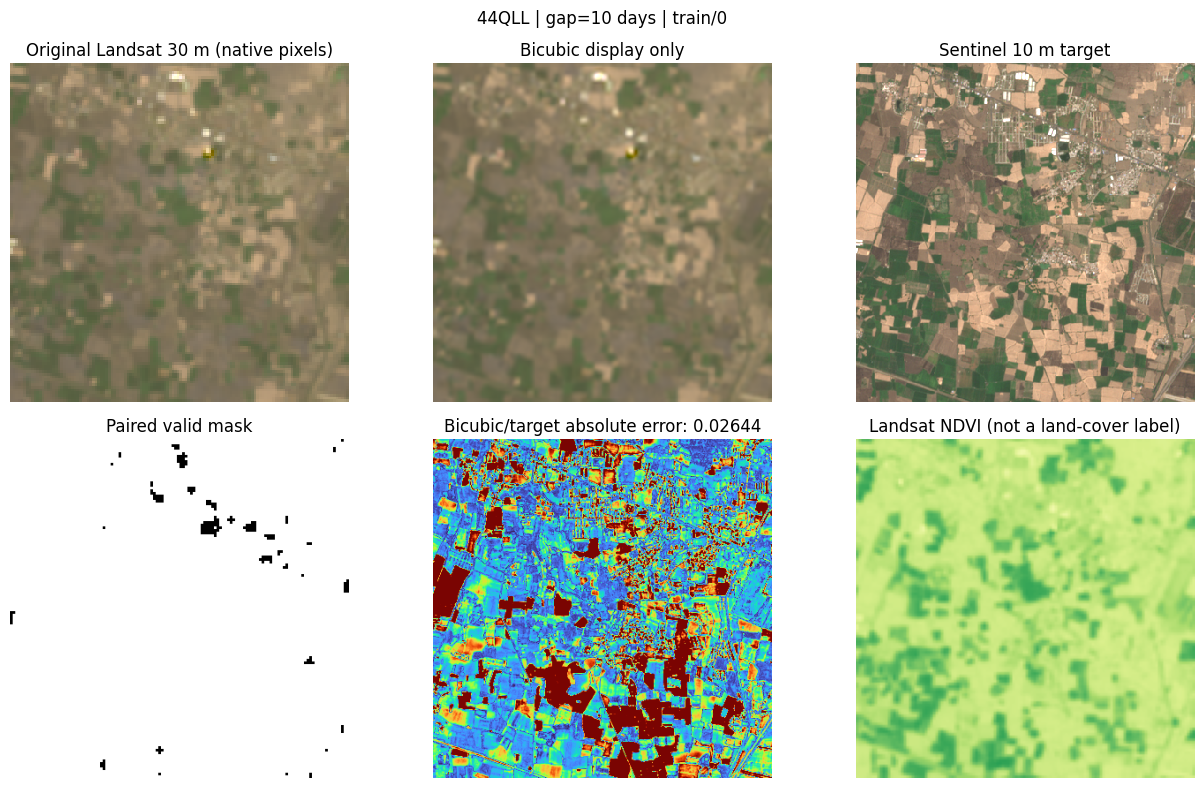

Inspect several pairs. Blur, calibration error, misregistration and date changes all contribute to paired MAE.


In [5]:
def inspect_pair(index=0, split="train"):
    selected = [r for r in records if r.split == split]
    record = selected[index]
    with np.load(record.patch) as patch:
        lr = torch.from_numpy(patch["lr"]).float()
        hr = torch.from_numpy(patch["hr"]).float()
        valid = patch["valid_mask_hr"][0].astype(bool)
        ms = patch["lr_ms"].copy() if "lr_ms" in patch else None
    up = F.interpolate(lr[None], size=hr.shape[-2:], mode="bicubic", align_corners=False)[0]
    error = (up - hr).abs().mean(0).numpy()
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for ax, image, title in zip(axes[0], (lr, up, hr), ("Original Landsat 30 m (native pixels)", "Bicubic display only", "Sentinel 10 m target")):
        ax.imshow((image.clamp(0, 0.3) / 0.3).pow(1/1.4).permute(1,2,0), interpolation="nearest")
        ax.set_title(title)
    axes[1,0].imshow(valid, cmap="gray", vmin=0, vmax=1)
    axes[1,0].set_title("Paired valid mask")
    axes[1,1].imshow(error, cmap="turbo", vmin=0, vmax=0.05)
    axes[1,1].set_title(f"Bicubic/target absolute error: {error[valid].mean():.5f}")
    if ms is not None:
        ndvi = (ms[3] - ms[0]) / np.maximum(ms[3] + ms[0], 1e-6)
        axes[1,2].imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
        axes[1,2].set_title("Landsat NDVI (not a land-cover label)")
    else:
        axes[1,2].imshow(np.abs(np.gradient(hr.mean(0).numpy(), axis=0)), cmap="gray")
        axes[1,2].set_title("Target spatial gradient")
    for ax in axes.flat: ax.axis("off")
    fig.suptitle(f"{record.tile_id} | gap={record.day_gap} days | {split}/{index}")
    fig.tight_layout()
    fig.savefig(FIGURE_ROOT / f"pair_{split}_{index}.png", dpi=150)
    plt.show()
    return record

inspect_pair(0)
print("Inspect several pairs. Blur, calibration error, misregistration and date changes all contribute to paired MAE.")


## 7. Run registry and bounded training helpers
The new four-way study shares one trained base and one VAE/LR-encoder warm-up.
Each diffusion run starts from that same VAE checkpoint, not from another expert run.
The base is frozen thereafter and checked tensor-by-tensor after every stage.
`generic_moe` and `reliability_moe` have the same parameter count and inference inputs;
only reliability supervision/acceptance differs. All experts receive denoising supervision.

An 'epoch' here is capped at 120 shuffled batches for frequent checkpoints; it is not
a complete dataset pass. Time caps, early stopping and epochs are all recorded. Compare
actual completed updates and time, not just epoch labels. Checkpoint restart is at the
last completed short epoch; an interrupted in-flight chunk is replayed.

In [6]:
import copy, yaml
RESULTS = {}

def save_state():
    value = {"manifest": str(MANIFEST), "manifest_sha256": sha256(MANIFEST), "results": RESULTS,
             "repository": str(REPOSITORY_DIR), "source_sha256": source_digest}
    temporary = SUITE_ROOT / "suite_state.json.tmp"
    temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
    temporary.replace(SUITE_ROOT / "suite_state.json")

if (SUITE_ROOT / "suite_state.json").exists():
    state = json.loads((SUITE_ROOT / "suite_state.json").read_text())
    if state["manifest_sha256"] != sha256(MANIFEST):
        raise ValueError("Saved registry uses a different manifest")
    RESULTS.update(state["results"])
save_state()

def calibration_for(profile):
    if profile not in ("rgb_harmonized_fidelity", "multispectral_guided_fidelity"):
        return None
    key = "lr_ms" if profile.startswith("multispectral") else "lr"
    path = SUITE_ROOT / "calibration" / f"{key}_train_only.json"
    lock_json(path.with_suffix(".lock.json"), {"manifest_sha256": sha256(MANIFEST), "key": key})
    if not path.exists():
        run([sys.executable, "-m", "geodiff_gan.cli.fit_radiometric", "--manifest", MANIFEST,
             "--output", path, "--condition-key", key, "--scale", 3,
             "--maximum-patches", 50 if FAST_DEV_RUN else 1000, "--seed", RANDOM_SEED], REPOSITORY_DIR)
    return path

def make_config(profile, root):
    config = experiment_config(REPOSITORY_DIR, profile, MANIFEST, root, experts=NUM_EXPERTS,
        top_k=TOP_K, crop_size=TRAIN_LR_CROP, calibration=calibration_for(profile),
        multispectral=NEW_MULTISPECTRAL, fast=FAST_DEV_RUN)
    config["training"]["validation_limit"] = max(config["training"]["validation_limit"], len({r.tile_id for r in records}))
    return config

def register(name, root, config, checkpoint):
    RESULTS[name] = {"root": str(root), "config": str(config), "checkpoint": str(checkpoint),
                     "checkpoint_sha256": sha256(checkpoint)}
    save_state()

def run_earlier(profile):
    if not RUN_EARLIER[profile]:
        print("Skipped extra-session profile:", profile)
        return
    if profile.startswith("multispectral") and not INCLUDE_MULTISPECTRAL:
        raise ValueError("Enable multispectral preparation first")
    root = EXPERIMENT_ROOT / (profile + "_resize_control")
    config = make_config(profile, root)
    parent = None
    for stage in ("base", "vae", "diffusion", "joint"):
        minutes = {**SHARED_MINUTES, **PER_EXPERIMENT_MINUTES}[stage]
        config_path, parent = run_stage(REPOSITORY_DIR, config, root, stage, parent=parent,
                                      epochs=EPOCHS[stage], minutes=minutes, fast=FAST_DEV_RUN)
    register(profile + "_resize_control", root, config_path, parent)

prefix = "ms" if NEW_MULTISPECTRAL else "rgb"
BASE_ROOT = EXPERIMENT_ROOT / f"{prefix}_residual_base"
BASE_CONFIG = make_config("residual_base", BASE_ROOT)
report = []
for profile in NEW_PROFILES:
    config = make_config(profile, EXPERIMENT_ROOT / f"{prefix}_{profile}")
    model = GeoDiffGAN.from_config(config)
    assert not any(isinstance(m, torch.nn.PixelShuffle) for m in model.modules())
    report.append({"profile": profile, "parameters": sum(p.numel() for p in model.parameters()),
                   "base_parameters": sum(p.numel() for p in model.base.parameters()),
                   "experts": config["model"]["diffusion_experts"], "top_k": config["model"]["diffusion_top_k"]})
    del model
display(pd.DataFrame(report))


,profile,parameters,base_parameters,experts,top_k
0,residual_base,3757482,76531,0,1
1,single_expert,3761160,76531,1,1
2,generic_moe,3764580,76531,3,1
3,reliability_moe,3764580,76531,3,1


### Optional earlier profile: `rgb_standard` (separate outputs, additional compute)

In [24]:
run_earlier("rgb_standard")


base train 1/12:  98%|█████████▊| 54/55 [00:03<00:00, 22.53batch/s, avg=0.0783, loss=0.0881, lr=1.00e-04]
                                                                                                         
base train 2/12:  95%|█████████▍| 52/55 [00:02<00:00, 21.46batch/s, avg=0.0516, loss=0.0494, lr=1.00e-04]
                                                                                                         
base train 3/12:  96%|█████████▋| 53/55 [00:02<00:00, 21.98batch/s, avg=0.0468, loss=0.0576, lr=1.00e-04]
                                                                                                         
base train 4/12:  95%|█████████▍| 52/55 [00:02<00:00, 21.51batch/s, avg=0.0469, loss=0.0273, lr=1.00e-04]
                                                                                                         
base train 5/12:  98%|█████████▊| 54/55 [00:02<00:00, 22.18batch/s, avg=0.0481, loss=0.1317, lr=1.00e-04]
                                              

### Optional earlier profile: `rgb_fidelity` (separate outputs, additional compute)

In [ ]:
run_earlier("rgb_fidelity")


base train 1/12:  98%|█████████▊| 54/55 [00:03<00:00, 22.73batch/s, avg=0.3330, loss=0.2580, lr=1.00e-04]
                                                                                                         
base train 2/12:  95%|█████████▍| 52/55 [00:02<00:00, 21.42batch/s, avg=0.1478, loss=0.1405, lr=1.00e-04]
                                                                                                         
base train 3/12: 100%|██████████| 55/55 [00:02<00:00, 23.51batch/s, avg=0.1369, loss=0.1591, lr=1.00e-04]
                                                                                                         
base train 4/12:  45%|████▌     | 25/55 [00:01<00:01, 21.17batch/s, avg=0.1357, loss=0.0745, lr=1.00e-04]

### Optional earlier profile: `multispectral_fidelity` (separate outputs, additional compute)

In [29]:
run_earlier("multispectral_fidelity")


### Optional earlier profile: `rgb_harmonized_fidelity` (separate outputs, additional compute)

In [30]:
run_earlier("rgb_harmonized_fidelity")


### Optional earlier profile: `multispectral_guided_fidelity` (separate outputs, additional compute)

In [31]:
run_earlier("multispectral_guided_fidelity")


[vae] resuming from /kaggle/working/geodiff-tiles-moe-v1/experiments/multispectral_guided_fidelity_resize_control/runs/vae/vae_epoch_0007.pt at epoch 9


vae train 9/10:  98%|█████████▊| 54/55 [00:06<00:00, 12.38batch/s, avg=0.1883, loss=0.2129, lr=1.00e-04]
                                                                                                        
vae train 10/10: 100%|██████████| 55/55 [00:04<00:00, 13.67batch/s, avg=0.1867, loss=0.1107, lr=1.00e-04]
                                                                                                         
diffusion train 1/10:  98%|█████████▊| 54/55 [00:06<00:00, 15.59batch/s, avg=0.3342, loss=0.8346, lr=1.00e-04]
                                                                                                              
diffusion train 2/10: 100%|██████████| 55/55 [00:04<00:00, 14.92batch/s, avg=0.2666, loss=0.0068, lr=1.00e-04]
                                                                                                              
diffusion train 3/10:  98%|█████████▊| 54/55 [00:04<00:00, 14.69batch/s, avg=0.2681, loss=0.3097, lr=1.00e-04]
                       

## 8. Experiment A: train the updated base only

In [12]:
BASE_CONFIG_PATH, BASE_CHECKPOINT = run_stage(REPOSITORY_DIR, BASE_CONFIG, BASE_ROOT, "base",
    epochs=EPOCHS["base"], minutes=SHARED_MINUTES["base"], fast=FAST_DEV_RUN)
register(f"{prefix}_residual_base", BASE_ROOT, BASE_CONFIG_PATH, BASE_CHECKPOINT)
print("Selected shared base:", BASE_CHECKPOINT)


Selected shared base: /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/runs/base/base_best.pt


## 9. Train the shared VAE, LR encoder and decoder warm-up once

In [13]:
VAE_ROOT = EXPERIMENT_ROOT / f"{prefix}_shared_vae"
VAE_CONFIG = make_config("residual_base", VAE_ROOT)
VAE_CONFIG_PATH, VAE_CHECKPOINT = run_stage(REPOSITORY_DIR, VAE_CONFIG, VAE_ROOT, "vae",
    parent=BASE_CHECKPOINT, epochs=EPOCHS["vae"], minutes=SHARED_MINUTES["vae"], fast=FAST_DEV_RUN)
print("Shared VAE lineage:", VAE_CHECKPOINT)

def run_new(profile):
    root = EXPERIMENT_ROOT / f"{prefix}_{profile}"
    config = make_config(profile, root)
    parent = VAE_CHECKPOINT
    for stage in ("diffusion", "joint"):
        config_path, parent = run_stage(REPOSITORY_DIR, config, root, stage, parent=parent,
            epochs=EPOCHS[stage], minutes=PER_EXPERIMENT_MINUTES[stage], fast=FAST_DEV_RUN)
    register(f"{prefix}_{profile}", root, config_path, parent)
    return RESULTS[f"{prefix}_{profile}"]


Shared VAE lineage: /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_shared_vae/runs/vae/vae_best.pt


## Experiment B: one-expert control

In [14]:
display(run_new("single_expert"))


{'root': '/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_single_expert',
 'config': '/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_single_expert/configs/joint.yaml',
 'checkpoint': '/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_single_expert/runs/joint/joint_best.pt',
 'checkpoint_sha256': 'e785b97239db006adc5599eb060a1dcde40b6ec5ef5c85783acd513c6e29cc9d'}

## Experiment C: generic MoE

In [15]:
display(run_new("generic_moe"))


{'root': '/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_generic_moe',
 'config': '/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_generic_moe/configs/joint.yaml',
 'checkpoint': '/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_generic_moe/runs/joint/joint_best.pt',
 'checkpoint_sha256': 'c02e5f7da8306e75d7604dcecd8518b5bd4c10c1b08b0a19a684d96da3bf903e'}

## Experiment D: reliability-supervised MoE

In [16]:
display(run_new("reliability_moe"))


{'root': '/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_reliability_moe',
 'config': '/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_reliability_moe/configs/joint.yaml',
 'checkpoint': '/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_reliability_moe/runs/joint/joint_best.pt',
 'checkpoint_sha256': '30d8d0aed673bd7437b6a786fe074765e4b8d021434ad32686e276e5ecffdcb4'}

## 10. Validate all available models, with the same full patches and sampling seeds
Model selection uses validation, not test. Final residual scale is **1.0**; the base-only
control uses scale 0. A model that cannot beat its own base is a failed refinement,
even when it beats bicubic. VAE teacher-forced metrics are not inference metrics.
Raw reflectance range 0..1 is kept throughout; do not compare these numbers directly
with other papers using clip03, uint8, different crops, or different scene pairs.
For the time-limited screening run, validation is capped at 64 tile-interleaved patches.
Use `EVAL_LIMIT=None` in a new evaluation directory for a complete validation report.

In [17]:
def evaluate_result(name, split="val"):
    item = RESULTS[name]
    root = Path(item["root"]) / "evaluation" / split
    base_only = name.endswith("residual_base")
    limit = TEST_EVAL_LIMIT if split == "test" else EVAL_LIMIT
    if split == "val" and limit is not None:
        limit = max(limit, len({r.tile_id for r in records}))
    settings = {"checkpoint_sha256": sha256(item["checkpoint"]), "config_sha256": sha256(item["config"]),
                "manifest_sha256": sha256(MANIFEST), "split": split, "limit": limit,
                "samples": 1 if base_only else EVAL_SAMPLES, "steps": 1 if base_only else EVAL_STEPS,
                "residual_scale": 0.0 if base_only else 1.0}
    lock_json(root / "evaluation_lock.json", settings)
    metric_path = root / "model/metrics.json"
    if not metric_path.exists():
        command = [sys.executable, "-m", "geodiff_gan.cli.evaluate", "--config", item["config"],
            "--checkpoint", item["checkpoint"], "--output", root / "model", "--split", split,
            "--samples", settings["samples"], "--steps", settings["steps"],
            "--residual-scale", settings["residual_scale"], "--back-projection-steps", 0,
            "--no-text", "--device", "cuda", "--progress", "compact"]
        if limit is not None: command += ["--limit", limit]
        run(command, REPOSITORY_DIR)
    baseline_path = root / "baselines.json"
    if not baseline_path.exists():
        command = [sys.executable, "-m", "geodiff_gan.cli.baselines", "--config", item["config"],
            "--base-checkpoint", item["checkpoint"], "--output", baseline_path, "--split", split,
            "--device", "cuda", "--progress", "quiet"]
        if limit is not None: command += ["--limit", limit]
        run(command, REPOSITORY_DIR)
    return {"experiment": name, **json.loads(metric_path.read_text())}

validation_table = pd.DataFrame([evaluate_result(name, "val") for name in RESULTS])
validation_table.to_csv(SUITE_ROOT / "validation_summary.csv", index=False)
display(validation_table[["experiment", "count", "psnr", "base_psnr", "psnr_delta_vs_base", "ssim",
                          "l1", "edge_f1", "ergas", "sam_degrees", "uiqi", "scc", "fraction_beating_base_psnr"]])


+ /usr/bin/python3 -m geodiff_gan.cli.evaluate --config /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/configs/base.yaml --checkpoint /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/runs/base/base_best.pt --output /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/evaluation/val/model --split val --samples 1 --steps 1 --residual-scale 0.0 --back-projection-steps 0 --no-text --device cuda --progress compact --limit 64
[evaluate] device=cuda (Tesla T4) torch=2.10.0+cu128 cuda=12.8
[evaluate] amp=True
[evaluate] building GeoDiff-GAN
[evaluate] loading checkpoint /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/runs/base/base_best.pt
[evaluate] text conditioning disabled; using zero context
[evaluate] remote-sensing metrics enabled: ERGAS, SAM, UIQI, sCC
[evaluate] loading val dataset
[evaluate] plan patches=28 samples=1 steps=1 diffusion_unet_passes=28
[evaluate] patch 1/28 sample 1/1 sample_eta=0s
[evaluate] patch 1

,experiment,count,psnr,base_psnr,psnr_delta_vs_base,ssim,l1,edge_f1,ergas,sam_degrees,uiqi,scc,fraction_beating_base_psnr
0,rgb_residual_base,28,34.503326,34.503326,0.000000,0.856089,0.013188,0.000275,5.441756,1.882497,0.565985,0.145803,0.000000
1,rgb_single_expert,28,34.844252,34.503326,0.340925,0.876864,0.012407,0.055204,5.260652,1.926655,0.626431,0.171395,0.964286
2,rgb_generic_moe,28,34.847552,34.503326,0.344226,0.876197,0.012427,0.043112,5.260175,1.922602,0.621918,0.170023,1.000000
3,rgb_reliability_moe,28,34.844512,34.503326,0.341185,0.877036,0.012403,0.059323,5.258778,1.929115,0.627150,0.175473,0.964286


## 11. Save comparison plots and paired validation confidence intervals

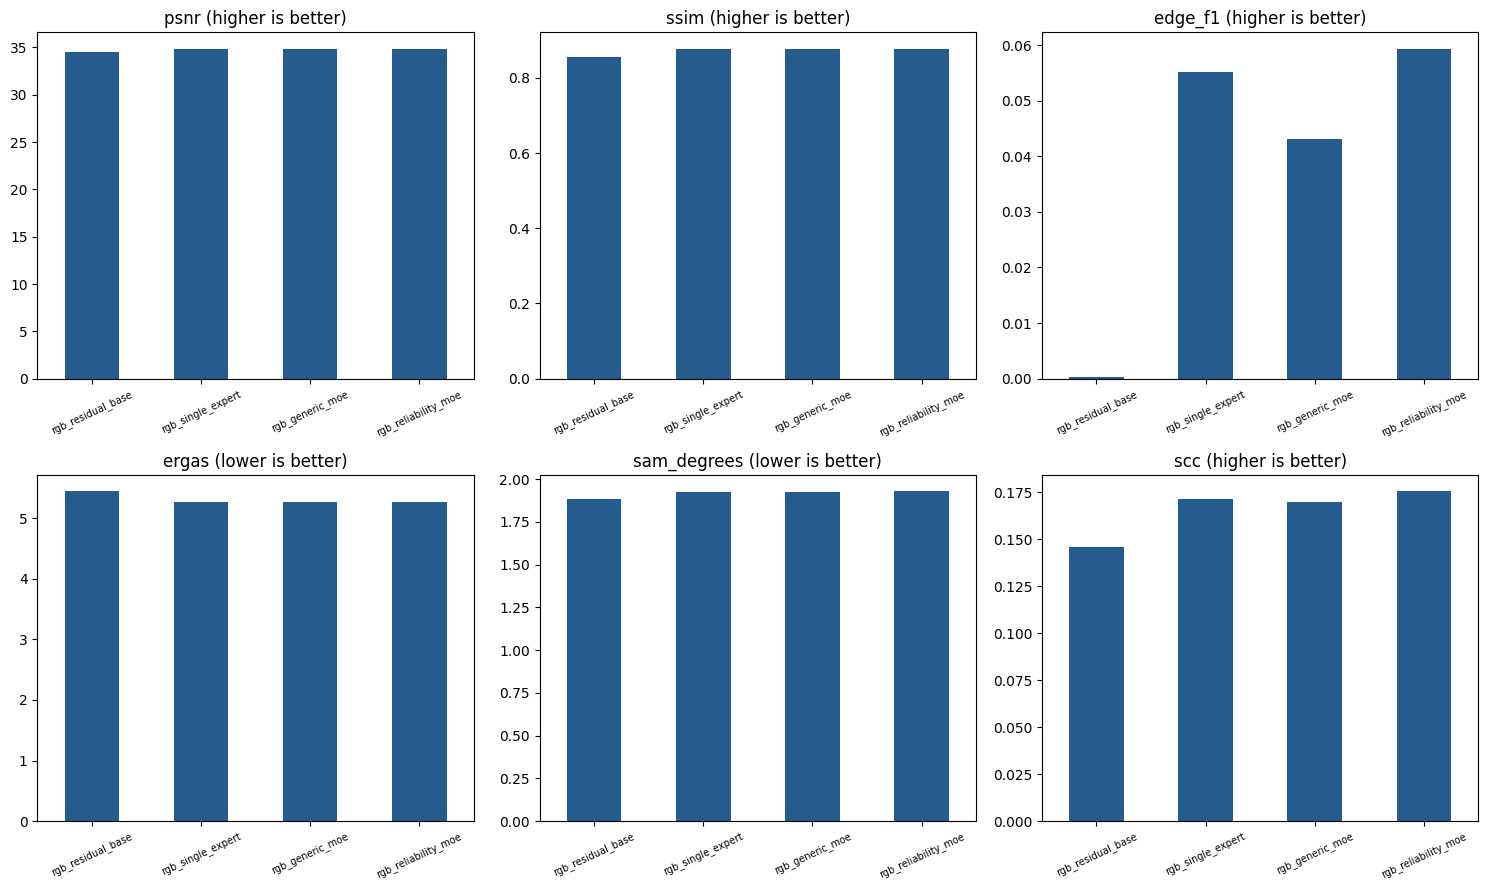

,experiment,mean_delta,ci_low,ci_high,fraction_beating_base
0,rgb_residual_base,0.000000,0.000000,0.000000,0.000000
1,rgb_single_expert,0.340925,0.262258,0.426549,0.964286
2,rgb_generic_moe,0.344226,0.270910,0.424626,1.000000
3,rgb_reliability_moe,0.341185,0.261494,0.427547,0.964286


Patch bootstrap is descriptive: adjacent/overlapping patches are correlated. Use tile-level resampling for geographic claims.


In [18]:
def plot_summary(table, split):
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for axis, metric in zip(axes.flat, ("psnr", "ssim", "edge_f1", "ergas", "sam_degrees", "scc")):
        table.plot.bar(x="experiment", y=metric, ax=axis, legend=False, color="#265b8e")
        axis.set_title(metric + (" (lower is better)" if metric in ("ergas", "sam_degrees") else " (higher is better)"))
        axis.set_xlabel("")
        axis.tick_params(axis="x", labelsize=7, rotation=25)
    fig.tight_layout()
    fig.savefig(FIGURE_ROOT / f"{split}_metrics.png", dpi=170)
    plt.show()

plot_summary(validation_table, "val")
bootstrap_rows = []
for name, item in RESULTS.items():
    rows = [json.loads(line) for line in (Path(item["root"]) / "evaluation/val/model/per_patch_metrics.jsonl").read_text().splitlines()]
    deltas = np.array([r["psnr_delta_vs_base"] for r in rows])
    rng = np.random.default_rng(RANDOM_SEED)
    bootstrap = np.array([rng.choice(deltas, size=len(deltas), replace=True).mean() for _ in range(2000)])
    bootstrap_rows.append({"experiment": name, "mean_delta": deltas.mean(),
        "ci_low": np.quantile(bootstrap, .025), "ci_high": np.quantile(bootstrap, .975),
        "fraction_beating_base": float((deltas > 0).mean())})
bootstrap_table = pd.DataFrame(bootstrap_rows)
bootstrap_table.to_csv(SUITE_ROOT / "validation_bootstrap.csv", index=False)
display(bootstrap_table)
print("Patch bootstrap is descriptive: adjacent/overlapping patches are correlated. Use tile-level resampling for geographic claims.")


## 12. Routing diagnostics: utilization, acceptance and actual training time

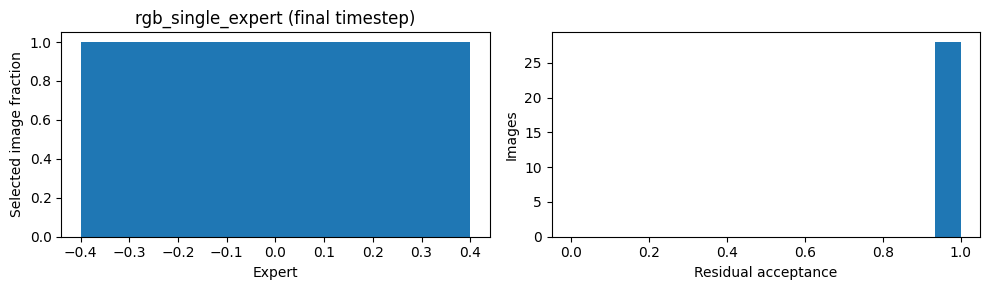

Dead experts: []


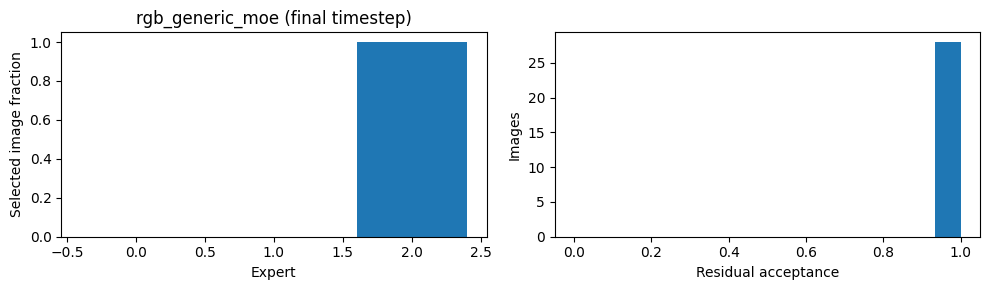

Dead experts: [0, 1]


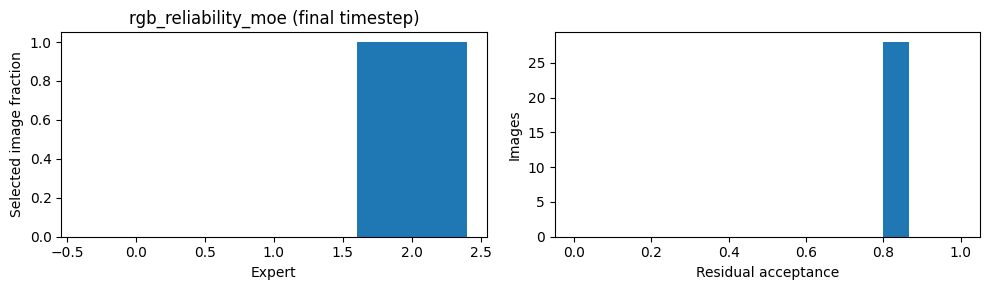

Dead experts: [0, 1]


,experiment,stage,best_epoch,completed_epochs,batches,optimizer_step_attempts,stage_minutes
0,rgb_residual_base,base,6,9,495,252,0.699107
1,rgb_single_expert,diffusion,9,10,550,280,1.139196
2,rgb_single_expert,joint,6,6,330,168,2.173560
3,rgb_generic_moe,diffusion,9,10,550,280,1.158215
4,rgb_generic_moe,joint,4,6,330,168,2.202532
5,rgb_reliability_moe,diffusion,10,10,550,280,1.609662
6,rgb_reliability_moe,joint,6,6,330,168,2.269285


Training loss/usage histories: [PosixPath('/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_shared_vae/runs/vae/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_generic_moe/runs/diffusion/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_generic_moe/runs/joint/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_single_expert/runs/diffusion/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_single_expert/runs/joint/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_reliability_moe/runs/diffusion/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_reliability_moe/runs/joint/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/runs/base/training_history.jsonl')]


In [20]:
history_rows = []
from geodiff_gan.training.checkpoint import latest_stage_checkpoint
for name, item in RESULTS.items():
    root = Path(item["root"])
    path = root / "evaluation/val/model/per_patch_metrics.jsonl"
    rows = [json.loads(line) for line in path.read_text().splitlines()]
    routed = [row for row in rows if row.get("expert_weights")]
    if routed:
        weights = np.asarray([row["expert_weights"] for row in routed])
        acceptance = np.asarray([row["router_acceptance"] for row in routed])
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        axes[0].bar(np.arange(weights.shape[1]), (weights > 0).mean(0))
        axes[0].set(xlabel="Expert", ylabel="Selected image fraction", title=name + " (final timestep)")
        axes[1].hist(acceptance, bins=15, range=(0, 1))
        axes[1].set(xlabel="Residual acceptance", ylabel="Images")
        fig.tight_layout(); fig.savefig(FIGURE_ROOT / f"{name}_routing.png", dpi=150); plt.show()
        print("Dead experts:", np.where((weights > 0).sum(0) == 0)[0].tolist())
    for done in root.glob("runs/*/completed.json"):
        stage = done.parent.name
        # Compact checkpoint headers still require trusted local torch files.
        saved = json.loads(done.read_text())
        payload = torch.load(saved["checkpoint"], map_location="cpu", weights_only=False)
        last = torch.load(latest_stage_checkpoint(done.parent, stage), map_location="cpu", weights_only=False)
        history_rows.append({"experiment": name, "stage": stage, "best_epoch": payload["epoch"] + 1,
                             "completed_epochs": last["epoch"] + 1,
                             "batches": last["extra"].get("total_train_batches"),
                             "optimizer_step_attempts": last["extra"].get("total_optimizer_step_attempts"),
                             "stage_minutes": last["extra"].get("stage_elapsed_seconds", 0) / 60,
                             "best_metrics": payload["extra"]["metrics"]})
        del payload, last
(SUITE_ROOT / "training_selection.json").write_text(json.dumps(history_rows, indent=2))
display(pd.DataFrame(history_rows).drop(columns=["best_metrics"], errors="ignore"))
print("Training loss/usage histories:", list(EXPERIMENT_ROOT.glob("*/runs/*/training_history.jsonl")))


## 13. Locked test evaluation (enable after reviewing validation)
No settings are selected on these results. Every available model uses the same test
manifest, full 128->384 patches, sample count and seeds. A smoke-run limit is not a
publishable evaluation. Leave the test set closed while debugging or changing the design.

+ /usr/bin/python3 -m geodiff_gan.cli.evaluate --config /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/configs/base.yaml --checkpoint /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/runs/base/base_best.pt --output /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/evaluation/test/model --split test --samples 1 --steps 1 --residual-scale 0.0 --back-projection-steps 0 --no-text --device cuda --progress compact
[evaluate] device=cuda (Tesla T4) torch=2.10.0+cu128 cuda=12.8
[evaluate] amp=True
[evaluate] building GeoDiff-GAN
[evaluate] loading checkpoint /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/runs/base/base_best.pt
[evaluate] text conditioning disabled; using zero context
[evaluate] remote-sensing metrics enabled: ERGAS, SAM, UIQI, sCC
[evaluate] loading test dataset
[evaluate] plan patches=28 samples=1 steps=1 diffusion_unet_passes=28
[evaluate] patch 1/28 sample 1/1 sample_eta=0s
[evaluate] patch 1/28 comp

,experiment,count,psnr,base_psnr,psnr_delta_vs_base,ssim,l1,edge_f1,ergas,sam_degrees,uiqi,scc
0,rgb_residual_base,28,33.268022,33.268022,0.000000,0.834731,0.014892,0.000626,6.421803,1.895372,0.515338,0.144619
1,rgb_single_expert,28,33.563612,33.268022,0.295590,0.858116,0.014037,0.068142,6.239099,1.953285,0.577046,0.171350
2,rgb_generic_moe,28,33.566256,33.268022,0.298234,0.857227,0.014067,0.055460,6.239467,1.947397,0.572120,0.169810
3,rgb_reliability_moe,28,33.564590,33.268022,0.296568,0.858368,0.014028,0.071161,6.236502,1.957896,0.577891,0.175773


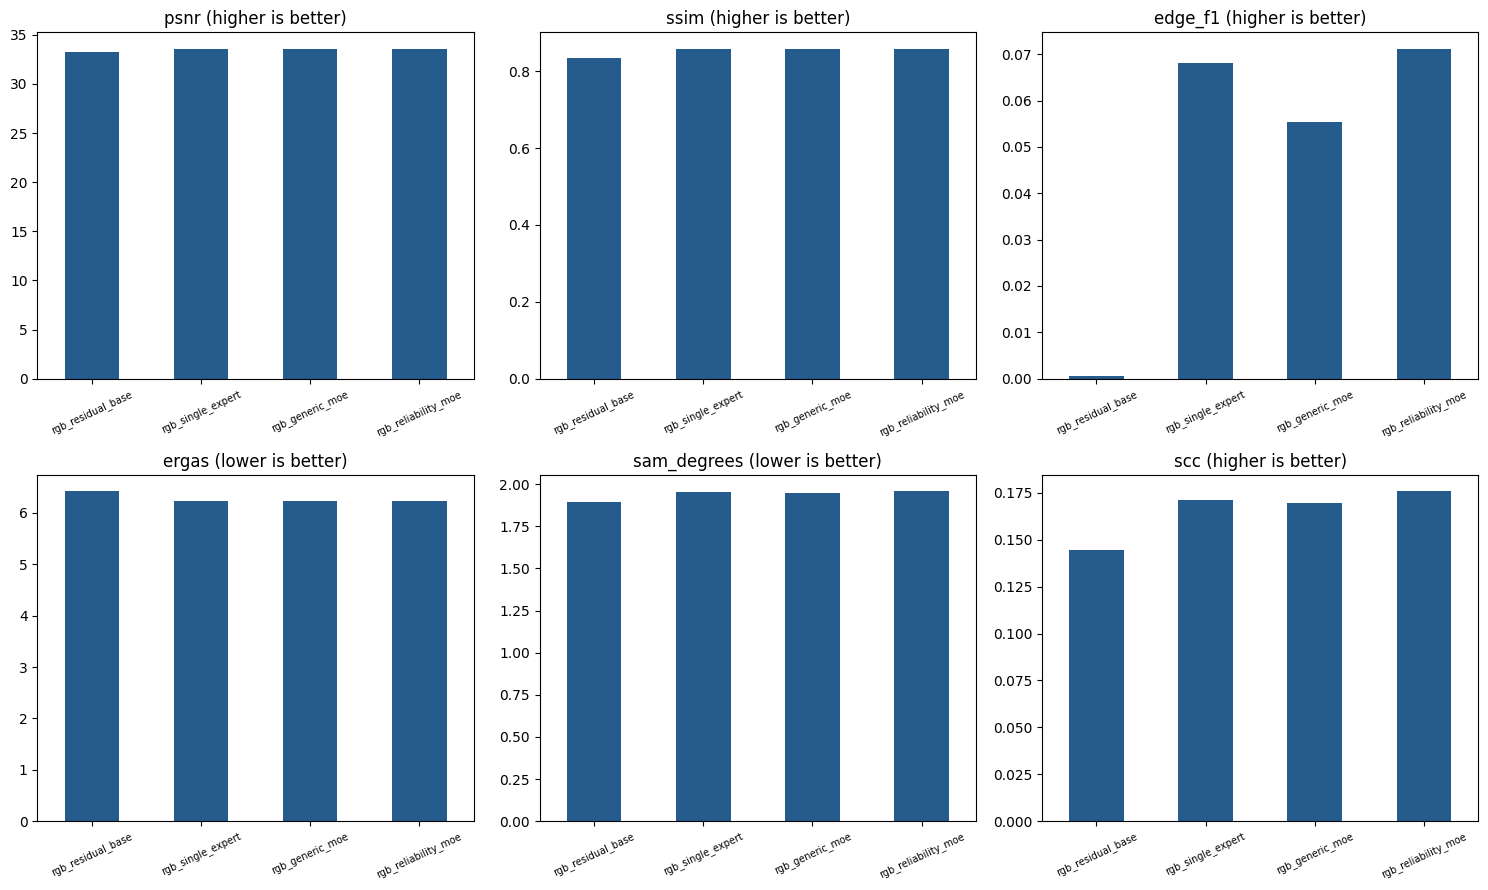

In [21]:
# Set True here once validation choices are final, then run this cell.
if RUN_TEST_EVALUATION:
    test_table = pd.DataFrame([evaluate_result(name, "test") for name in RESULTS])
    test_table.to_csv(SUITE_ROOT / "test_summary.csv", index=False)
    display(test_table[["experiment", "count", "psnr", "base_psnr", "psnr_delta_vs_base", "ssim",
                        "l1", "edge_f1", "ergas", "sam_degrees", "uiqi", "scc"]])
    plot_summary(test_table, "test")
else:
    print("Test remains locked. Set RUN_TEST_EVALUATION=True after validation review.")


## 14. Indexed comparison: original LR, each model and HR (at most three panels per row)

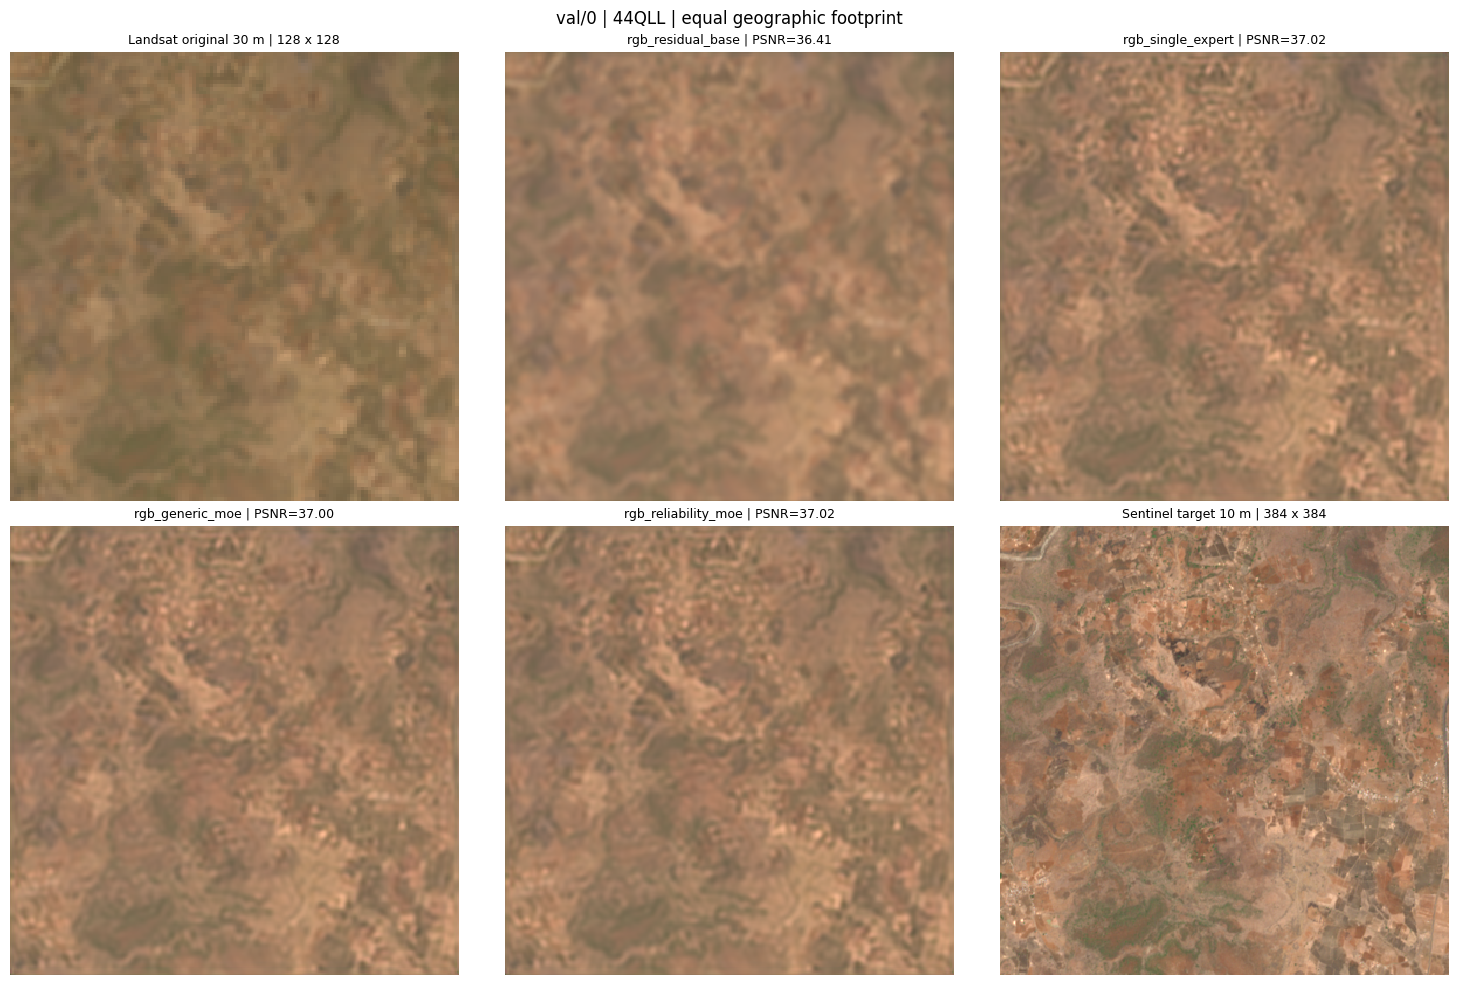

Saved: /kaggle/working/geodiff-tiles-moe-v1/figures/compare_val_0_1788230650.png


{'record': {'caption': '',
  'col': 4320,
  'day_gap': 10,
  'landsat_acquisition': '2026-05-27',
  'landsat_product': 'LC09_L2SP_144044_20260527_20260528_02_T1',
  'license_id': 'usgs-public-domain+copernicus-free-full-open',
  'patch': '/kaggle/working/geodiff-tiles-moe-v1/dataset/patches/44QLL/d45a821822b1c8cc/r09216_c04320.npz',
  'row': 9216,
  'scale': 3,
  'sentinel_acquisition': '2026-05-17',
  'sentinel_product': 'S2C_MSIL2A_20260517T050651_N0512_R019_T44QLL_20260517T100909.SAFE',
  'source': 'landsat8_9_c2_l2_to_sentinel2_l2a',
  'source_product': 'S2C_MSIL2A_20260517T050651_N0512_R019_T44QLL_20260517T100909.SAFE',
  'split': 'val',
  'target_crs': 'EPSG:32644',
  'target_transform': [10.0, 0.0, 343200.0, 0.0, -10.0, 2507880.0],
  'tile_id': '44QLL',
  'valid_fraction': 0.9876708984375},
 'display': 'Fixed common reflectance stretch; metrics use unchanged arrays',
 'models': {'rgb_residual_base': {'psnr': np.float64(36.41006729643749),
   'l1': 0.011037214659154415,
   'exper

{'record': {'caption': '',
  'col': 4320,
  'day_gap': 10,
  'landsat_acquisition': '2026-05-27',
  'landsat_product': 'LC09_L2SP_144044_20260527_20260528_02_T1',
  'license_id': 'usgs-public-domain+copernicus-free-full-open',
  'patch': '/kaggle/working/geodiff-tiles-moe-v1/dataset/patches/44QLL/d45a821822b1c8cc/r09216_c04320.npz',
  'row': 9216,
  'scale': 3,
  'sentinel_acquisition': '2026-05-17',
  'sentinel_product': 'S2C_MSIL2A_20260517T050651_N0512_R019_T44QLL_20260517T100909.SAFE',
  'source': 'landsat8_9_c2_l2_to_sentinel2_l2a',
  'source_product': 'S2C_MSIL2A_20260517T050651_N0512_R019_T44QLL_20260517T100909.SAFE',
  'split': 'val',
  'target_crs': 'EPSG:32644',
  'target_transform': [10.0, 0.0, 343200.0, 0.0, -10.0, 2507880.0],
  'tile_id': '44QLL',
  'valid_fraction': 0.9876708984375},
 'display': 'Fixed common reflectance stretch; metrics use unchanged arrays',
 'models': {'rgb_residual_base': {'psnr': np.float64(36.41006729643749),
   'l1': 0.011037214659154415,
   'exper

In [22]:
from geodiff_gan.experiments.tile_viewer import SavedTileResults

def show_results(index=0, split="test", models=None, show_base=False, show_errors=False, display_max=0.3):
    viewer = SavedTileResults(SUITE_ROOT)
    panels, details = viewer.panels(index, split, models, show_base, display_max=display_max, errors=show_errors)
    columns = min(3, len(panels))
    rows = (len(panels) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 5 * rows), squeeze=False)
    for axis in axes.flat: axis.axis("off")
    for axis, (image, title) in zip(axes.flat, panels):
        if image.ndim == 2:
            axis.imshow(image, cmap="turbo", vmin=0, vmax=0.05)
        else:
            axis.imshow(viewer.display(image, display_max), interpolation="nearest")
        axis.set_title(title, fontsize=9)
    fig.suptitle(f"{split}/{index} | {details['record']['tile_id']} | equal geographic footprint")
    fig.tight_layout()
    destination = FIGURE_ROOT / f"compare_{split}_{index}_{int(time.time())}.png"
    fig.savefig(destination, dpi=180)
    plt.show()
    print("Saved:", destination)
    display(details)
    return details

show_results(0, split="val")
# After final testing: show_results(25, show_base=True)
# Individual models: show_results(0, models=[f"{prefix}_reliability_moe"])


In [32]:
# Set True here once validation choices are final, then run this cell.
if RUN_TEST_EVALUATION:
    test_table = pd.DataFrame([evaluate_result(name, "test") for name in RESULTS])
    test_table.to_csv(SUITE_ROOT / "test_summary.csv", index=False)
    display(test_table[["experiment", "count", "psnr", "base_psnr", "psnr_delta_vs_base", "ssim",
                        "l1", "edge_f1", "ergas", "sam_degrees", "uiqi", "scc"]])
    plot_summary(test_table, "test")
else:
    print("Test remains locked. Set RUN_TEST_EVALUATION=True after validation review.")


ValueError: Existing run differs: /kaggle/working/geodiff-tiles-moe-v1/experiments/rgb_residual_base/evaluation/test/evaluation_lock.json. Use a NEW run directory; old artifacts were preserved.

## 15. Standalone saved-results Gradio cell
After a kernel restart, run **only this cell** if the repository and suite are still
on disk. No GPU is needed. Next/back, tile/split filters, a base-checkbox, metrics,
routing weights and a large gallery are included. Empty model selection shows just
the original Landsat and Sentinel target. This never trains or launches inference.

Set `START_SERVER=True` explicitly. A public share URL exposes the selected data;
leave `PUBLIC_SHARE=False` unless this is intended. Use a tunnel only with appropriate permission.

In [ ]:
from pathlib import Path
import sys, subprocess
START_SERVER = True
PUBLIC_SHARE = True
VIEW_REPOSITORY = Path("/kaggle/working/geodiff-3x-continued-moe")
VIEW_SUITE = Path("/kaggle/working/geodiff-tiles-moe-v1")  # Change to smoke or restored root if needed.
if START_SERVER:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gradio>=4.44,<6"], check=True)
    sys.path.insert(0, str(VIEW_REPOSITORY / "src"))
    from geodiff_gan.experiments.tile_viewer import build_app
    app = build_app(VIEW_SUITE)
    app.launch(share=PUBLIC_SHARE, server_name="0.0.0.0")
else:
    print("Set START_SERVER=True and the correct VIEW_SUITE to launch the read-only explorer.")


## 16. Export the evidence needed for a progress report
The small report ZIP includes configs/lineage, per-patch metrics, tables, plots and up
to three cached predictions per model/split. It excludes raw scenes, prepared patches,
credentials and checkpoints. For resuming training, save the **whole Kaggle notebook
output**, not just this report. Nothing is deleted.

In [ ]:
from datetime import datetime
report_zip = SUITE_ROOT.parent / f"{SUITE_ROOT.name}_report_{datetime.now():%Y%m%d_%H%M%S}.zip"
selected = set()
for pattern in ("*.json", "*.csv", "figures/*.png", "experiments/*/configs/*",
                "experiments/*/runs/*/*.json", "experiments/*/runs/*/*.jsonl",
                "experiments/*/evaluation/*/*.json", "experiments/*/evaluation/*/model/*.json",
                "experiments/*/evaluation/*/model/*.jsonl", "dataset/*.csv", "dataset/*lock.json"):
    selected.update(p for p in SUITE_ROOT.glob(pattern) if p.is_file())
for directory in SUITE_ROOT.glob("experiments/*/evaluation/*/model"):
    selected.update(sorted(directory.glob("*_uncertainty.npz"))[:3])
with zipfile.ZipFile(report_zip, "w", zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(selected): archive.write(path, path.relative_to(SUITE_ROOT))
print("Report:", report_zip, f"{report_zip.stat().st_size / 2**20:.1f} MiB")
from IPython.display import FileLink
display(FileLink(str(report_zip)))
